In [6]:
2+2

4

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory

# xy grid test 
filexy1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\RANS\nc files\flowdata_xy1m_mb_cartesian.nc'
filexy2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy2m_mb_cartesian.nc'
filexy4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy4m_mb_cartesian.nc'
filexy8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy8m_mb_cartesian.nc'
filexy16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy16m_mb_cartesian.nc'

# z grid test
filez1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
filez2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
filez4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z01m_4m_cartesian.nc'
filez8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z02m_8m_mb_cartesian.nc'
filez16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z04m_16m_mb_cartesian.nc'

files = {
    'xy=1m': filexy1m,
    'xy=2m': filexy2m,
    'xy=4m': filexy4m,
    'xy=8m': filexy8m,
    'xy=16m': filexy16m,
    'z=0.025m_1m' : filez1m,
    'z=0.05m_2m' : filez2m,
    'z=0.1m_4m' : filez4m,
    'z=0.2m_8m' : filez8m,
    'z=0.4m_16m' : filez16m
}

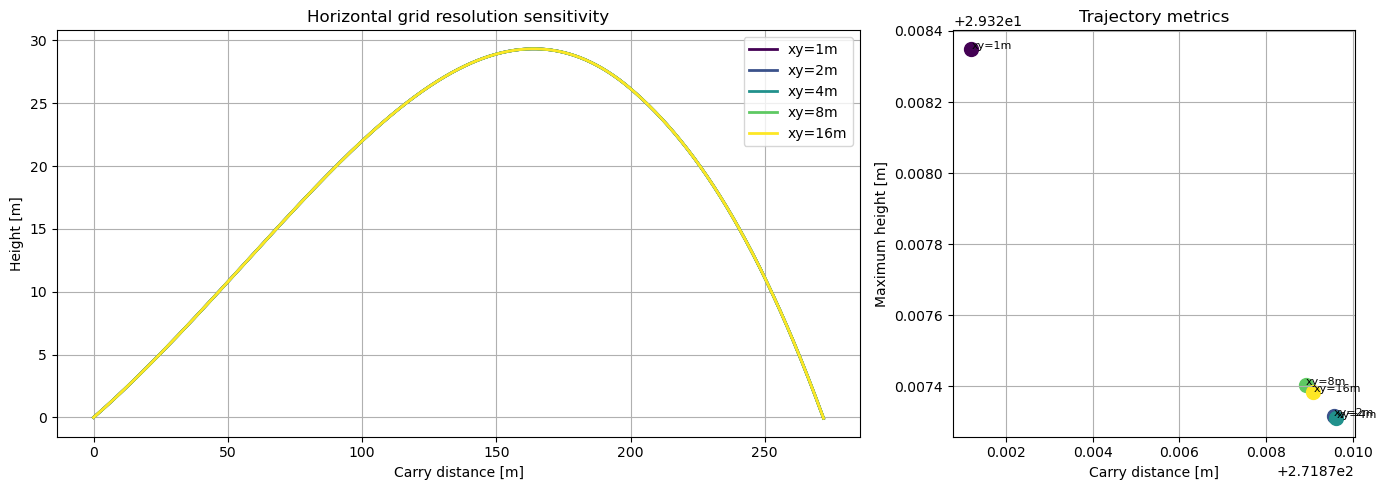

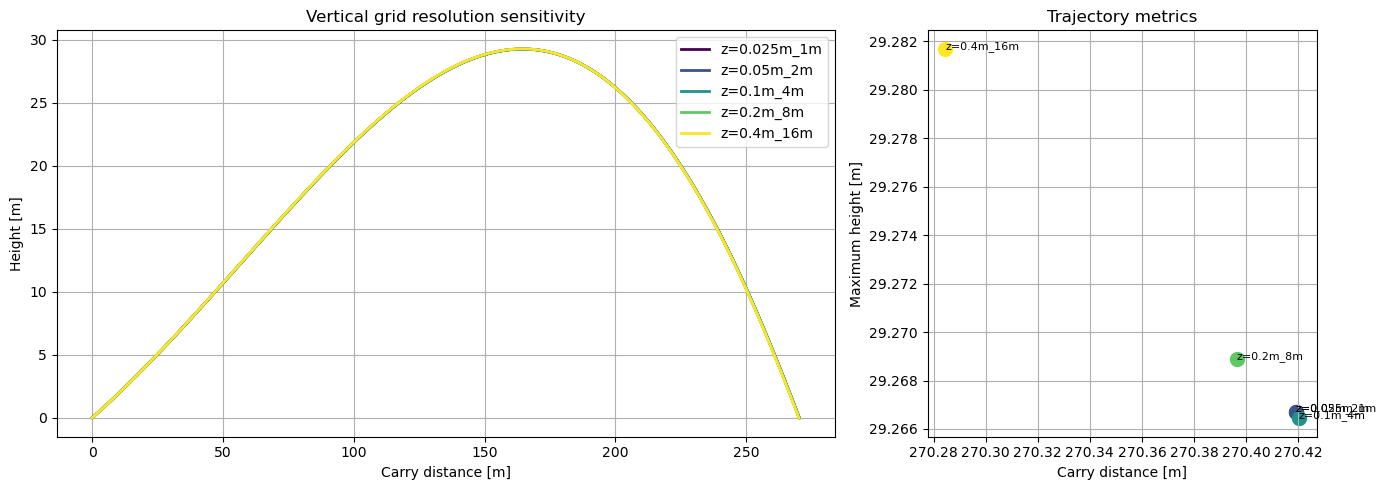


GRID FIDELITY ERRORS

Horizontal grid sensitivity


,Case,Abs Error [m],Percent Error [%],dx Error [m],dy Error [m],Carry [m],Max Height [m]
0,xy=2m,0.008370,0.003079,0.008370,-0.000012,271.879566,29.327317
1,xy=4m,0.008425,0.003099,0.008425,0.000005,271.879621,29.327311
2,xy=8m,0.007715,0.002838,0.007715,0.000007,271.878912,29.327405
3,xy=16m,0.007897,0.002905,0.007897,0.000004,271.879093,29.327383



Vertical grid sensitivity


,Case,Abs Error [m],Percent Error [%],dx Error [m],dy Error [m],Carry [m],Max Height [m]
0,z=0.05m_2m,0.000000,0.000000,0.000000,0.000000,270.418985,29.266721
1,z=0.1m_4m,0.001276,0.000472,0.001275,0.000012,270.420260,29.266443
2,z=0.2m_8m,0.022528,0.008331,-0.022528,0.000000,270.396457,29.268904
3,z=0.4m_16m,0.134473,0.049728,-0.134473,-0.000006,270.284512,29.281696


In [13]:
# ============================================================
# Error models
# ============================================================

def percent_distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]

    norm = np.sqrt(
        (ref_p[-1, 0] - ref_p[0, 0])**2 +
        (ref_p[-1, 1] - ref_p[0, 1])**2
    )

    return np.sqrt(dx**2 + dy**2) / norm * 100


def distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]

    return np.sqrt(dx**2 + dy**2)


def x_distance_error(ref_p, test_p):
    return test_p[-1, 0] - ref_p[-1, 0]


def y_distance_error(ref_p, test_p):
    return test_p[-1, 1] - ref_p[-1, 1]


# ============================================================
# Trajectory metrics
# ============================================================

def carry_distance(p):
    return p[-1, 0] - p[0, 0]


def max_height(p):
    return np.max(p[:, 2])


# ============================================================
# Solve trajectories
# ============================================================

trajectories = {}

for key, file in files.items():

    wind = WindField(profile='rans', ds=file)

    traj = Trajectory(
        ball_speed=76.44384,
        launch_angle=10.4,
        spin_rate=2545,
        spin_axis=0,
        wind=wind
    )

    traj.solve(solver='euler', dt=0.01)

    trajectories[key] = traj


# ============================================================
# XY GRID COMPARISON
# ============================================================

xy_keys = ['xy=1m', 'xy=2m', 'xy=4m', 'xy=8m', 'xy=16m']

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]}
)

colors = plt.cm.viridis(np.linspace(0, 1, len(xy_keys)))

# ------------------------------------------------------------
# Left: trajectories
# ------------------------------------------------------------

for i, key in enumerate(xy_keys):

    p = trajectories[key].p

    ax1.plot(
        p[:, 0],
        p[:, 2],
        linewidth=2,
        color=colors[i],
        label=key
    )

ax1.set_xlabel('Carry distance [m]')
ax1.set_ylabel('Height [m]')
ax1.set_title('Horizontal grid resolution sensitivity')
ax1.grid(True)
ax1.legend()

# ------------------------------------------------------------
# Right: carry vs apex
# ------------------------------------------------------------

for i, key in enumerate(xy_keys):

    p = trajectories[key].p

    carry = carry_distance(p)
    apex = max_height(p)

    ax2.scatter(
        carry,
        apex,
        s=100,
        color=colors[i],
        label=key
    )

    ax2.text(
        carry,
        apex,
        key,
        fontsize=8
    )

ax2.set_xlabel('Carry distance [m]')
ax2.set_ylabel('Maximum height [m]')
ax2.set_title('Trajectory metrics')
ax2.grid(True)

plt.tight_layout()
plt.show()


z_keys = [
    'z=0.025m_1m',
    'z=0.05m_2m',
    'z=0.1m_4m',
    'z=0.2m_8m',
    'z=0.4m_16m'
]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]}
)

colors = plt.cm.viridis(np.linspace(0, 1, len(z_keys)))

# ------------------------------------------------------------
# Left: trajectories
# ------------------------------------------------------------

for i, key in enumerate(z_keys):

    p = trajectories[key].p

    ax1.plot(
        p[:, 0],
        p[:, 2],
        linewidth=2,
        color=colors[i],
        label=key
    )

ax1.set_xlabel('Carry distance [m]')
ax1.set_ylabel('Height [m]')
ax1.set_title('Vertical grid resolution sensitivity')
ax1.grid(True)
ax1.legend()

# ------------------------------------------------------------
# Right: carry vs apex
# ------------------------------------------------------------

for i, key in enumerate(z_keys):

    p = trajectories[key].p

    carry = carry_distance(p)
    apex = max_height(p)

    ax2.scatter(
        carry,
        apex,
        s=100,
        color=colors[i]
    )

    ax2.text(
        carry,
        apex,
        key,
        fontsize=8
    )

ax2.set_xlabel('Carry distance [m]')
ax2.set_ylabel('Maximum height [m]')
ax2.set_title('Trajectory metrics')
ax2.grid(True)

plt.tight_layout()
plt.show()

print('\n============================================================')
print('GRID FIDELITY ERRORS')
print('============================================================')

ref_xy = trajectories['xy=1m'].p
xy_rows = []
for key in ['xy=2m', 'xy=4m', 'xy=8m', 'xy=16m']:

    test_p = trajectories[key].p

    xy_rows.append({
        'Case': key,
        'Abs Error [m]':
            distance_error(ref_xy, test_p),

        'Percent Error [%]':
            percent_distance_error(ref_xy, test_p),

        'dx Error [m]':
            x_distance_error(ref_xy, test_p),

        'dy Error [m]':
            y_distance_error(ref_xy, test_p),

        'Carry [m]':
            carry_distance(test_p),

        'Max Height [m]':
            max_height(test_p)
    })

xy_df = pd.DataFrame(xy_rows)

print('\nHorizontal grid sensitivity')
display(xy_df.round(6))

ref_z = trajectories['z=0.025m_1m'].p
z_rows = []
for key in [
    'z=0.05m_2m',
    'z=0.1m_4m',
    'z=0.2m_8m',
    'z=0.4m_16m'
]:

    test_p = trajectories[key].p

    z_rows.append({
        'Case': key,
        'Abs Error [m]':
            distance_error(ref_z, test_p),

        'Percent Error [%]':
            percent_distance_error(ref_z, test_p),

        'dx Error [m]':
            x_distance_error(ref_z, test_p),

        'dy Error [m]':
            y_distance_error(ref_z, test_p),

        'Carry [m]':
            carry_distance(test_p),

        'Max Height [m]':
            max_height(test_p)
    })

z_df = pd.DataFrame(z_rows)

print('\nVertical grid sensitivity')
display(z_df.round(6))